# 03: Qualitative Inference Results

Load evaluation outputs from `scripts/evaluate.py`, inspect per-model predictions vs ground truth,
and visualize B-Rep graphs with GT / predicted face overlays.

In [9]:
import os, sys, json, glob
from pathlib import Path


def find_project_root(start: Path) -> Path:
    candidates = [
        start,
        *start.parents,
        start / "hanomi-repo",
        Path("/kaggle/working/hanomi-repo"),
        Path("/kaggle/input/hanomi-feature-repo"),
    ]
    for candidate in candidates:
        if (candidate / "src").exists() and (candidate / "configs").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root(Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

try:
    from torch_geometric.utils import to_networkx
    from src.data.h5_dataset import MFCADPlusPlusDataset, LABEL_NAMES
    from src.evaluation.metrics import _face_iou
    HAS_DEPS = True
except ImportError as exc:
    HAS_DEPS = False
    MISSING = str(exc)

if HAS_DEPS:
    print('All dependencies available.')
else:
    print(f'Missing dependency: {MISSING}')
    print('Install with:  pip install torch torch-geometric networkx h5py matplotlib')

All dependencies available.


## 1. Load Evaluation Results

In [10]:
RESULTS_PATH = os.path.join('..', 'results/runs/run_001/eval', 'per_model_results.json')

results = []

if os.path.isfile(RESULTS_PATH):
    with open(RESULTS_PATH, 'r') as f:
        results = json.load(f)
    print(f'Loaded {len(results)} model results from {RESULTS_PATH}')
else:
    print(f'[!] {RESULTS_PATH} not found. Run scripts/evaluate.py first.')

RESULTS_AVAILABLE = len(results) > 0

Loaded 4702 model results from ../results/runs/run_001/eval/per_model_results.json


## 2. Per-Model Prediction Summary

For each model show predicted vs GT instances, per-instance face IoU, and confidence.

In [11]:
if not RESULTS_AVAILABLE:
    print('No results — skipping per-model summary.')
else:
    for entry in results:
        model = entry.get('model_file', '?')
        preds = entry.get('predicted_instances', [])
        gts   = entry.get('gt_instances', [])
        print(f'\nModel: {model}  ({entry.get("feature_type", "?")})')
        print(f'  Predicted instances: {len(preds)}   GT instances: {len(gts)}')
        print(f'  P={entry.get("precision",0):.3f}  R={entry.get("recall",0):.3f}  F1={entry.get("f1",0):.3f}')

        for pi, pred in enumerate(preds):
            p_faces = set(pred.get('face_ids', []))
            conf = pred.get('confidence', 0.0)
            print(f'  Pred [{pi}]  faces={sorted(p_faces)}  confidence={conf:.3f}')
            for gi, gt in enumerate(gts):
                g_faces = set(gt.get('face_ids', []))
                iou = _face_iou(list(p_faces), list(g_faces))
                tp = p_faces & g_faces
                fp = p_faces - g_faces
                fn = g_faces - p_faces
                print(f'    vs GT [{gi}]  IoU={iou:.3f}  TP={sorted(tp)}  FP={sorted(fp)}  FN={sorted(fn)}')


Model: 53133  (through_hole)
  Predicted instances: 2   GT instances: 2
  P=1.000  R=1.000  F1=1.000
  Pred [0]  faces=[20]  confidence=1.000
    vs GT [0]  IoU=1.000  TP=[20]  FP=[]  FN=[]
    vs GT [1]  IoU=0.000  TP=[]  FP=[20]  FN=[7]
  Pred [1]  faces=[7]  confidence=0.999
    vs GT [0]  IoU=0.000  TP=[]  FP=[7]  FN=[20]
    vs GT [1]  IoU=1.000  TP=[7]  FP=[]  FN=[]

Model: 36217  (through_hole)
  Predicted instances: 2   GT instances: 2
  P=1.000  R=1.000  F1=1.000
  Pred [0]  faces=[17]  confidence=0.996
    vs GT [0]  IoU=1.000  TP=[17]  FP=[]  FN=[]
    vs GT [1]  IoU=0.000  TP=[]  FP=[17]  FN=[18]
  Pred [1]  faces=[18]  confidence=0.995
    vs GT [0]  IoU=0.000  TP=[]  FP=[18]  FN=[17]
    vs GT [1]  IoU=1.000  TP=[18]  FP=[]  FN=[]

Model: 4954  (through_hole)
  Predicted instances: 2   GT instances: 1
  P=0.500  R=1.000  F1=0.667
  Pred [0]  faces=[13]  confidence=0.998
    vs GT [0]  IoU=1.000  TP=[13]  FP=[]  FN=[]
  Pred [1]  faces=[15, 16]  confidence=0.916
    vs GT

## 3. Load Graph Data & Visualize Overlays

Load the test H5 file with `MFCADPlusPlusDataset`, find models present in the results,
and render their B-Rep graphs with GT faces in blue and predicted faces in red.

In [12]:
PROJECT_ROOT = os.path.abspath('..')

CANDIDATE_H5 = [
    "/Users/anmolsen/Developer/MFCAD++_dataset/hierarchical_graphs/test_MFCAD++.h5",
    os.path.join(PROJECT_ROOT, 'MFCAD++_dataset', 'hierarchical_graphs', 'test_MFCAD++.h5'),
    os.path.join(PROJECT_ROOT, 'data', 'processed', 'test_MFCAD++.h5'),
]
KAGGLE_GLOB = '/kaggle/input/**/test_MFCAD++.h5'


def _find_h5():
    for p in CANDIDATE_H5:
        if os.path.isfile(p):
            return p
    for p in glob.glob(KAGGLE_GLOB, recursive=True):
        if os.path.isfile(p):
            return p
    return None


dataset = None

if not HAS_DEPS:
    print('Skipping dataset load (missing dependencies).')
else:
    h5_path = _find_h5()
    if h5_path is None:
        print('Test H5 not found. Searched:')
        for p in CANDIDATE_H5:
            print(f'  {p}')
    else:
        print(f'Loading: {h5_path}')
        dataset = MFCADPlusPlusDataset(h5_path)
        print(f'Dataset loaded: {len(dataset)} models')

DATASET_AVAILABLE = dataset is not None

Loading: /Users/anmolsen/Developer/MFCAD++_dataset/hierarchical_graphs/test_MFCAD++.h5
Dataset loaded: 8632 models


### Graph Visualization — GT vs Predicted Face Overlay

Nodes coloured:
- **Blue** — GT face only (FN)
- **Red** — Predicted face only (FP)
- **Purple** — Overlapping GT & predicted face (TP)
- **Grey** — Uninvolved face

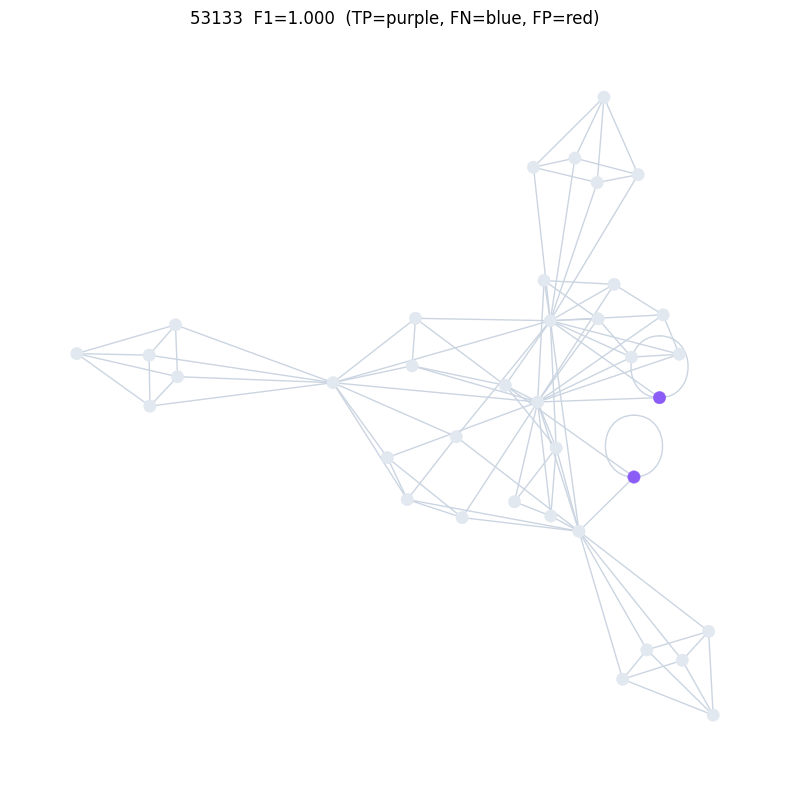

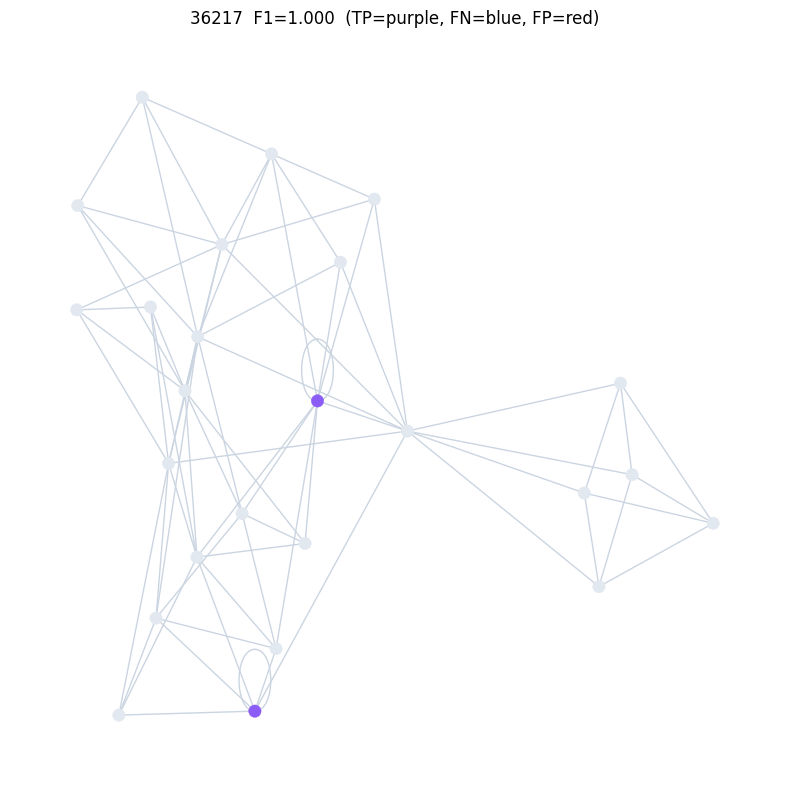

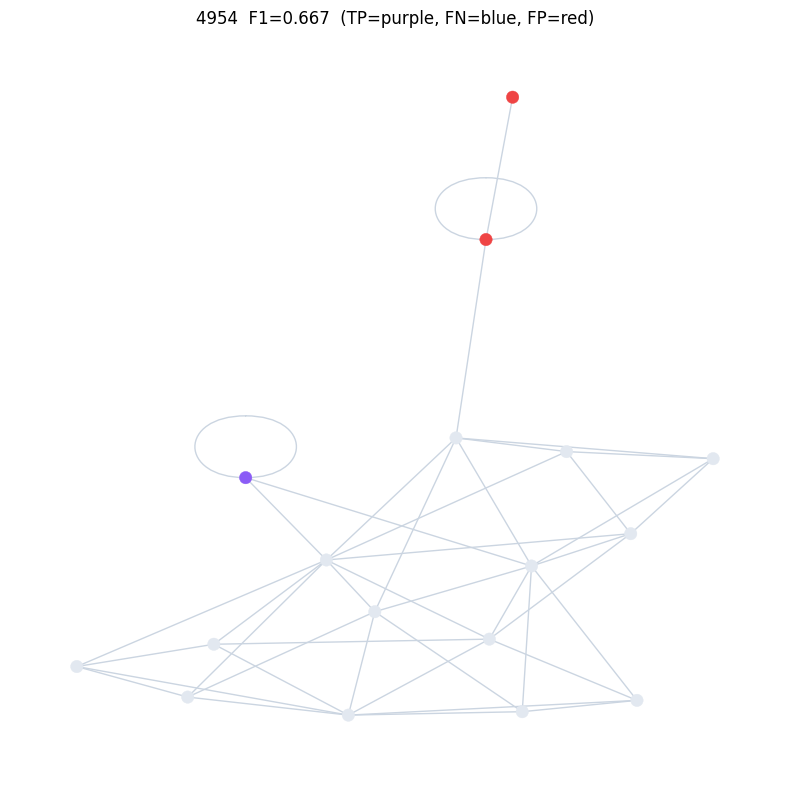

In [13]:
SEED = 42
N_VIS = 3

if not DATASET_AVAILABLE or not RESULTS_AVAILABLE:
    print('Missing dataset or results — skipping graph overlays.')
else:
    model_map = {g.model_id: g for g in dataset._graphs}
    vis_entries = results[:N_VIS]

    for entry in vis_entries:
        model_name = entry['model_file']
        data = model_map.get(model_name)
        if data is None:
            print(f'Model {model_name} not found in dataset — skipped.')
            continue

        gt_faces = set()
        for gi in entry.get('gt_instances', []):
            gt_faces.update(gi.get('face_ids', []))

        pred_faces = set()
        for pi in entry.get('predicted_instances', []):
            pred_faces.update(pi.get('face_ids', []))

        n_nodes = data.num_nodes
        colors = []
        for nid in range(n_nodes):
            in_gt = nid in gt_faces
            in_pred = nid in pred_faces
            if in_gt and in_pred:
                colors.append('#8B5CF6')
            elif in_gt:
                colors.append('#3B82F6')
            elif in_pred:
                colors.append('#EF4444')
            else:
                colors.append('#E2E8F0')

        G = to_networkx(data, to_undirected=True)
        pos = nx.spring_layout(G, seed=SEED)

        fig, ax = plt.subplots(figsize=(8, 8))
        nx.draw_networkx(
            G, pos=pos,
            node_size=80,
            node_color=colors,
            edge_color='#CBD5E1',
            linewidths=0.3,
            with_labels=False,
            ax=ax,
        )
        ax.set_title(
            f'{model_name}  F1={entry.get("f1",0):.3f}  '
            f'(TP=purple, FN=blue, FP=red)'
        )
        ax.axis('off')
        fig.tight_layout()
        plt.show()

## 4. Best / Worst Models by F1

In [14]:
N_SHOW = 5

if not RESULTS_AVAILABLE:
    print('No results — skipping best/worst summary.')
else:
    ranked = sorted(results, key=lambda e: e.get('f1', 0.0))
    best  = ranked[-N_SHOW:][::-1]
    worst = ranked[:N_SHOW]

    def _print_table(title, entries):
        print(f'\n=== {title} (top {N_SHOW}) ===')
        print(f'{"Model":<12} {"F1":>6} {"Prec":>6} {"Rec":>6}  {"#Pred":>5} {"#GT":>4}  {"Latency(ms)":>11}')
        print('-' * 60)
        for e in entries:
            print(
                f'{e.get("model_file","?"):<12} '
                f'{e.get("f1",0):>6.3f} '
                f'{e.get("precision",0):>6.3f} '
                f'{e.get("recall",0):>6.3f}  '
                f'{len(e.get("predicted_instances",[])):>5} '
                f'{len(e.get("gt_instances",[])):>4}  '
                f'{e.get("inference_ms",0):>11.1f}'
            )

    _print_table('Best models by F1', best)
    _print_table('Worst models by F1', worst)


=== Best models by F1 (top 5) ===
Model            F1   Prec    Rec  #Pred  #GT  Latency(ms)
------------------------------------------------------------
24464         1.000  1.000  1.000      1    1         10.4
32088         1.000  1.000  1.000      3    3         11.1
43238         1.000  1.000  1.000      1    1         14.2
31453         1.000  1.000  1.000      1    1          9.7
5502          1.000  1.000  1.000      1    1         10.3

=== Worst models by F1 (top 5) ===
Model            F1   Prec    Rec  #Pred  #GT  Latency(ms)
------------------------------------------------------------
58192         0.000  0.000  0.000      2    1         20.5
47503         0.000  0.000  0.000      3    1         14.4
48606         0.000  0.000  0.000      2    2         16.2
6732          0.000  0.000  0.000      1    1         12.6
21268         0.000  0.000  0.000      1    2         13.5


## 5. Confidence Score Distribution

Total predictions : 8782
Mean confidence   : 0.9361
Std               : 0.1050
Min               : 0.5141
Max               : 1.0000


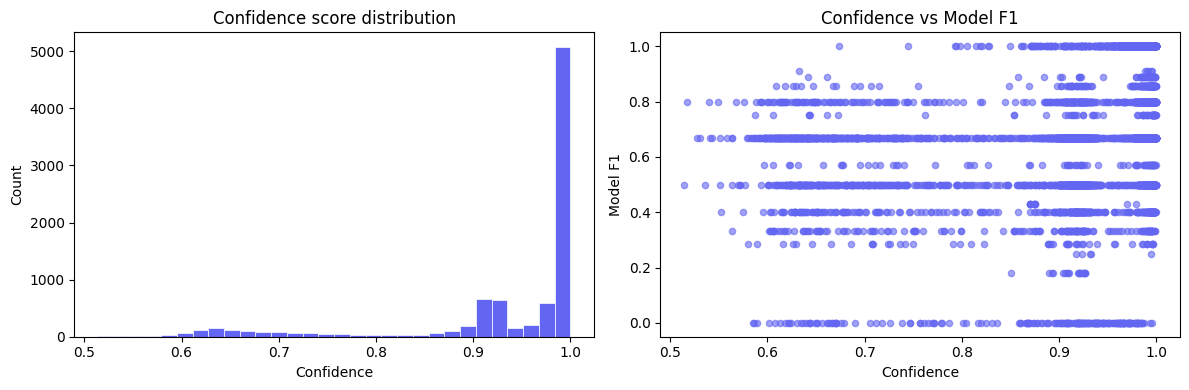

In [15]:
if not RESULTS_AVAILABLE:
    print('No results — skipping confidence distribution.')
else:
    all_conf = []
    for e in results:
        for inst in e.get('predicted_instances', []):
            all_conf.append(inst.get('confidence', 0.0))

    if not all_conf:
        print('No confidence scores found in results.')
    else:
        conf_arr = np.array(all_conf)
        print(f'Total predictions : {len(conf_arr)}')
        print(f'Mean confidence   : {conf_arr.mean():.4f}')
        print(f'Std               : {conf_arr.std():.4f}')
        print(f'Min               : {conf_arr.min():.4f}')
        print(f'Max               : {conf_arr.max():.4f}')

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].hist(conf_arr, bins=30, edgecolor='white', linewidth=0.5, color='#6366F1')
        axes[0].set_xlabel('Confidence')
        axes[0].set_ylabel('Count')
        axes[0].set_title('Confidence score distribution')

        f1_vals = [e.get('f1', 0.0) for e in results for _ in e.get('predicted_instances', [])]
        if len(f1_vals) == len(conf_arr):
            axes[1].scatter(conf_arr, f1_vals, alpha=0.6, s=20, color='#6366F1')
            axes[1].set_xlabel('Confidence')
            axes[1].set_ylabel('Model F1')
            axes[1].set_title('Confidence vs Model F1')
        else:
            f1_per_model = [e.get('f1', 0.0) for e in results]
            conf_per_model = [
                np.mean([i.get('confidence', 0) for i in e.get('predicted_instances', [])])
                for e in results
            ]
            axes[1].scatter(conf_per_model, f1_per_model, alpha=0.6, s=20, color='#6366F1')
            axes[1].set_xlabel('Mean confidence per model')
            axes[1].set_ylabel('Model F1')
            axes[1].set_title('Mean confidence vs F1')

        fig.tight_layout()
        plt.show()

## 6. F1 Score Distribution Across Models

Models evaluated : 4702
Mean F1          : 0.8290
Std              : 0.2417
Min              : 0.0000
Max              : 1.0000


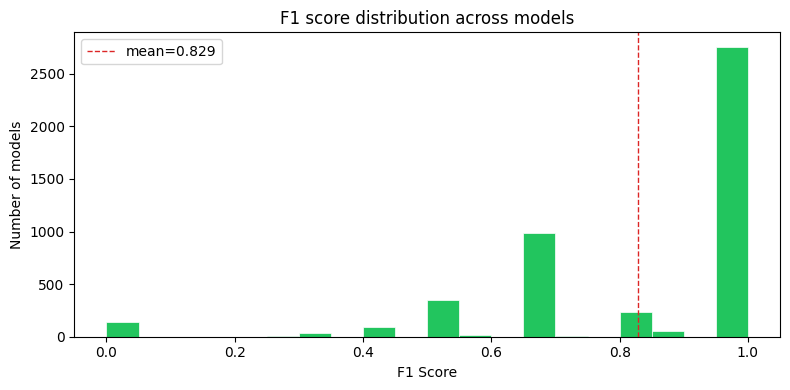

In [16]:
if not RESULTS_AVAILABLE:
    print('No results — skipping F1 distribution.')
else:
    f1_all = [e.get('f1', 0.0) for e in results]
    f1_arr = np.array(f1_all)

    print(f'Models evaluated : {len(f1_arr)}')
    print(f'Mean F1          : {f1_arr.mean():.4f}')
    print(f'Std              : {f1_arr.std():.4f}')
    print(f'Min              : {f1_arr.min():.4f}')
    print(f'Max              : {f1_arr.max():.4f}')

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(f1_arr, bins=20, edgecolor='white', linewidth=0.5, color='#22C55E')
    ax.axvline(f1_arr.mean(), color='#DC2626', linestyle='--', linewidth=1, label=f'mean={f1_arr.mean():.3f}')
    ax.set_xlabel('F1 Score')
    ax.set_ylabel('Number of models')
    ax.set_title('F1 score distribution across models')
    ax.legend()
    fig.tight_layout()
    plt.show()